## Improrting libraries

In [1]:
!pip install tensorflow
!pip install -q -U keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')
import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt

Mounted at /content/drive


## Importing the datasets

### Dataset stratification

In [3]:
# !pip install split-folders

In [4]:
# import splitfolders
# import os

In [5]:
# input_folder = '/content/drive/MyDrive/ml-datasets/painters/resized_training'
# output_folder = '/content/drive/MyDrive/ml-datasets/painters/stratified_dataset'

# split_ratio = (0.8, 0.1, 0.1)

# splitfolders.ratio(
#     input_folder,
#     output=output_folder,
#     seed=42,
#     ratio=split_ratio,
#     group_prefix=None,
#     move=False
# )

### Tensorflow datasets imports

In [14]:
train_directory = '/content/drive/MyDrive/ml-datasets/painters/stratified_dataset/train'
val_directory = '/content/drive/MyDrive/ml-datasets/painters/stratified_dataset/val'
test_directory = '/content/drive/MyDrive/ml-datasets/painters/stratified_dataset/test'

train = tf.keras.preprocessing.image_dataset_from_directory(
    train_directory,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    seed=42,
    shuffle=True,
    batch_size=256,
    image_size=(224, 224),
    verbose=True
)

val = tf.keras.preprocessing.image_dataset_from_directory(
    val_directory,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    seed=42,
    shuffle=True,
    batch_size=256,
    image_size=(224, 224),
    verbose=True
)

test = tf.keras.preprocessing.image_dataset_from_directory(
    test_directory,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    seed=42,
    shuffle=True,
    batch_size=256,
    image_size=(224, 224),
    verbose=True
)

Found 2456 files belonging to 27 classes.
Found 296 files belonging to 27 classes.
Found 327 files belonging to 27 classes.


27


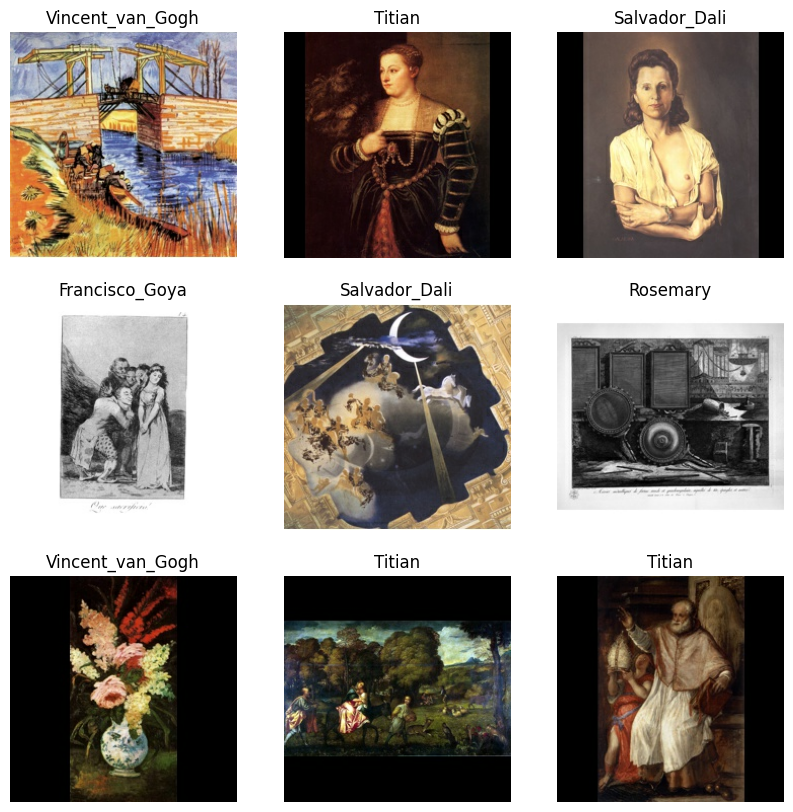

In [7]:
class_names = train.class_names
print(len(class_names))

plt.figure(figsize=(10, 10))
for images, labels in train.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
  break

# CNN Implementation

In [24]:
def model_builder(hp):
  # Define the model's input
  inputs = keras.Input(shape=(224, 224, 3))

  # Apply data augmentation layers sequentially to the tensor
  x = keras.layers.RandomFlip("horizontal")(inputs)
  x = keras.layers.RandomRotation(0.03)(x)
  x = keras.layers.RandomCrop(224, 224)(x)
  x = keras.layers.RandomZoom((-0.25, 0.25), (-0.25, 0.25))(x)

  # Load the base model and set it to non-trainable
  base_model = tf.keras.applications.EfficientNetB0(
      include_top=False,
      input_shape=(224, 224, 3),
      pooling='avg',
  )
  base_model.trainable = False

  # Pass the augmented input tensor to the base_model
  x = base_model(x)

  # Add custom top layers
  x = tf.keras.layers.Dropout(0.35)(x)

  hp_units = hp.Int('units (hidden1)', min_value=17, max_value=97, step=10)
  x = keras.layers.Dense(hp_units, activation='relu')(x)
  x = keras.layers.Dropout(0.35)(x)
  hp_units2 = hp.Int('unit (hidden2)', min_value=7, max_value=57, step=5)
  x = keras.layers.Dense(hp_units2, activation='relu')(x)
  x = keras.layers.Dropout(0.1)(x)
  outputs = tf.keras.layers.Dense(27, activation='softmax')(x)

  # Create the final model
  model = tf.keras.Model(inputs=inputs, outputs=outputs)

  hp_learning_rate = hp.Choice('learning_rate', values=[1e-1, 1e-2, 1e-3, 1e-4])
  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
      loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
      metrics=['accuracy']
  )

  return model

In [25]:
tuner = kt.Hyperband(
    model_builder,
    objective='val_accuracy',
    max_epochs=15,
    factor=3,
    directory='my_dir',
    project_name='best_params',
    overwrite=True
)

stop_early = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5
)

tuner.search(x=train, validation_data=val, epochs=50, callbacks=[stop_early])


Trial 30 Complete [00h 02m 54s]
val_accuracy: 0.625

Best val_accuracy So Far: 0.6689189076423645
Total elapsed time: 00h 39m 27s


In [26]:
best_params = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_params)
model = tuner.hypermodel.build(best_params)
history = model.fit(train, validation_data=val, epochs=20)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.1957 - loss: 2.9418 - val_accuracy: 0.4324 - val_loss: 2.0649
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 854ms/step - accuracy: 0.3518 - loss: 2.2362 - val_accuracy: 0.4899 - val_loss: 1.7243
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 932ms/step - accuracy: 0.4225 - loss: 1.9582 - val_accuracy: 0.5270 - val_loss: 1.5522
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 958ms/step - accuracy: 0.4675 - loss: 1.7203 - val_accuracy: 0.5608 - val_loss: 1.4304
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 863ms/step - accuracy: 0.5050 - loss: 1.6283 - val_accuracy: 0.5709 - val_loss: 1.4233
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 896ms/step - accuracy: 0.5316 - loss: 1.4935 - val_accuracy: 0.5811 - val_loss: 1.3808
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 931ms/step - accuracy: 0.5610 - loss: 1.4598 - val_accuracy: 0.6149 - val_loss: 1.2949
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 932ms/step - accuracy: 0.5687 - loss: 1.4091 - val_accuracy: 

In [27]:
model.evaluate(test)
model.save('100epochs.keras')

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step - accuracy: 0.6940 - loss: 1.0625


In [28]:
val_acc_per_epoch = history.history['val_accuracy']
best_epoch = val_acc_per_epoch.index(max(val_acc_per_epoch)) + 1
print('Best epoch: %d' % (best_epoch,))
hypermodel = tuner.hypermodel.build(best_params)
hypermodel.fit(train, validation_data=val, epochs=best_epoch, validation_split=0.2)

Best epoch: 19
Epoch 1/19
10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.1784 - loss: 3.0253 - val_accuracy: 0.3514 - val_loss: 2.1607
Epoch 2/19
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 837ms/step - accuracy: 0.3424 - loss: 2.2751 - val_accuracy: 0.4966 - val_loss: 1.8266
Epoch 3/19
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 918ms/step - accuracy: 0.4117 - loss: 2.0123 - val_accuracy: 0.5169 - val_loss: 1.5448
Epoch 4/19
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 932ms/step - accuracy: 0.4661 - loss: 1.7911 - val_accuracy: 0.5709 - val_loss: 1.4094
Epoch 5/19
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 883ms/step - accuracy: 0.5005 - loss: 1.6489 - val_accuracy: 0.5777 - val_loss: 1.3309
Epoch 6/19
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 882ms/step - accuracy: 0.5212 - loss: 1.5316 - val_accuracy: 0.6149 - val_loss: 1.2978
Epoch 7/19
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 927ms/step - accuracy: 0.5481 - loss: 1.4558 - val_accuracy: 0.6284 - val_loss: 1.2416
Epoch 8/19
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 915ms/step - accuracy: 0.5591 - loss: 1.4432 -

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.6691 - loss: 1.1231
[test loss, test accuracy]: [1.1113777160644531, 0.6697247624397278]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Model prediction (probabilities): [[7.82883912e-02 1.00967036e-05 1.10885242e-06 4.85928831e-05
  2.45247036e-02 2.26915143e-02 8.00582394e-03 6.87666759e-02
  4.99336893e-05 5.02988087e-06 5.72874036e-04 1.37770985e-04
  2.73370300e-04 7.94014661e-04 1.17128622e-02 9.37302015e-04
  4.30964210e-05 6.04715338e-03 3.91536921e-01 5.35989820e-05
  5.81309723e-06 1.07172124e-01 9.35069460e-04 3.11723561e-03
  2.66655743e-01 1.43694881e-04 7.46944360e-03]]


Predicted class: Rembrandt
True class: Rembrandt


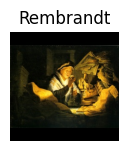

In [30]:
eval_result = hypermodel.evaluate(test)
print("[test loss, test accuracy]:", eval_result)

for images, labels in test.take(1):
  ax = plt.subplot(3, 3, 1)
  plt.imshow(images[2].numpy().astype("uint8"))
  plt.title(class_names[labels[2]])
  plt.axis("off")

  # Add a batch dimension to the single image before prediction
  single_image = np.expand_dims(images[2].numpy(), axis=0)
  predictions = model.predict(single_image)
  print("Model prediction (probabilities):", predictions)
  predicted_class = np.argmax(predictions)
  print(f"\n\nPredicted class: {class_names[predicted_class]}")
  print(f"True class: {class_names[labels[2]]}")
  break